In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load the dataset
df = pd.read_csv('labels.csv')

#basic overview of dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst look:\n", df.head())

Shape: (16266, 34)

Columns: ['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'iluminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']

Data types:
 image_id                     object
patient_id                    int64
camera                       object
patient_age                 float64
comorbidities                object
diabetes_time_y              object
insuline                     object
patient_sex                   int64
exam_eye                      int64
diabetes                     object
nationality                  object
optic_disc                   object
vessels                       int64
macula

In [4]:
# Check missing values and basic stats
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nUnique patients:", df['patient_id'].nunique())
print("Unique images:", df['image_id'].nunique())

print("\nDisease label distribution:")
disease_cols = ['diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 
                'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 
                'drusens', 'hemorrhage', 'retinal_detachment', 
                'myopic_fundus', 'increased_cup_disc', 'other']
print(df[disease_cols].sum().sort_values(ascending=False))

print("\nDiabetic retinopathy cases:")
print(df['diabetic_retinopathy'].value_counts())

print("\nImage quality:")
print(df['quality'].value_counts())

Missing values per column:
patient_age         5445
comorbidities       8236
diabetes_time_y    14356
insuline           14552
dtype: int64

Unique patients: 8524
Unique images: 16266

Disease label distribution:
increased_cup_disc          3202
drusens                     2807
diabetic_retinopathy        1046
other                        758
macular_edema                402
amd                          366
scar                         290
hypertensive_retinopathy     283
myopic_fundus                268
nevus                        134
vascular_occlusion           103
hemorrhage                    96
retinal_detachment             7
dtype: int64

Diabetic retinopathy cases:
diabetic_retinopathy
0    15220
1     1046
Name: count, dtype: int64

Image quality:
quality
Adequate      14279
Inadequate     1987
Name: count, dtype: int64


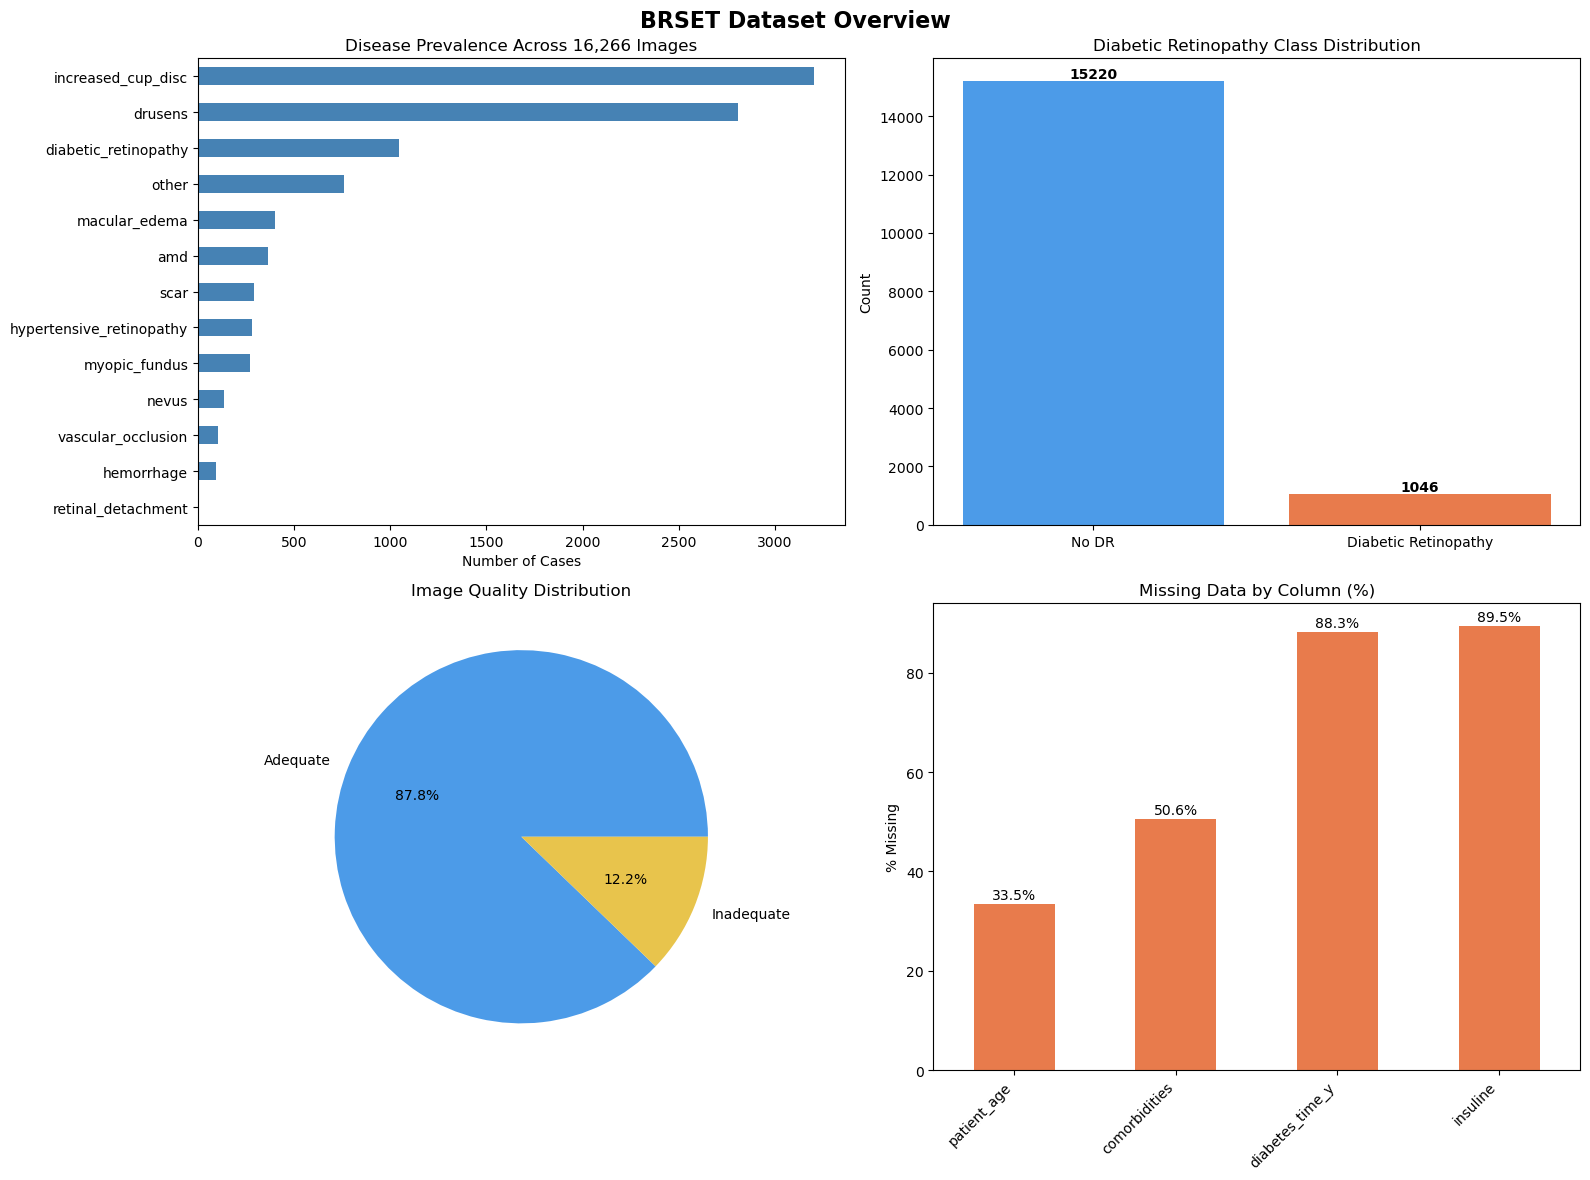

Saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('BRSET Dataset Overview', fontsize=16, fontweight='bold')

# Chart 1 — Disease prevalence
disease_counts = df[disease_cols].sum().sort_values(ascending=True)
disease_counts.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Disease Prevalence Across 16,266 Images')
axes[0,0].set_xlabel('Number of Cases')

# Chart 2 — DR class distribution
axes[0,1].bar(['No DR', 'Diabetic Retinopathy'], 
              df['diabetic_retinopathy'].value_counts().values,
              color=['#4C9BE8', '#E87B4C'])
axes[0,1].set_title('Diabetic Retinopathy Class Distribution')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(df['diabetic_retinopathy'].value_counts().values):
    axes[0,1].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Chart 3 — Image quality
axes[1,0].pie(df['quality'].value_counts().values,
              labels=['Adequate', 'Inadequate'],
              autopct='%1.1f%%',
              colors=['#4C9BE8', '#E8C44C'])
axes[1,0].set_title('Image Quality Distribution')

# Chart 4 — Missing data
missing = df.isnull().sum()[df.isnull().sum() > 0]
missing_pct = (missing / len(df) * 100).round(1)
missing_pct.plot(kind='bar', ax=axes[1,1], color='#E87B4C')
axes[1,1].set_title('Missing Data by Column (%)')
axes[1,1].set_ylabel('% Missing')
axes[1,1].set_xticklabels(missing_pct.index, rotation=45, ha='right')
for i, v in enumerate(missing_pct.values):
    axes[1,1].text(i, v + 1, f'{v}%', ha='center', fontsize=10)

plt.tight_layout()
save_path = os.path.expanduser('~/brset_overview.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

After quality filter: 14279 images


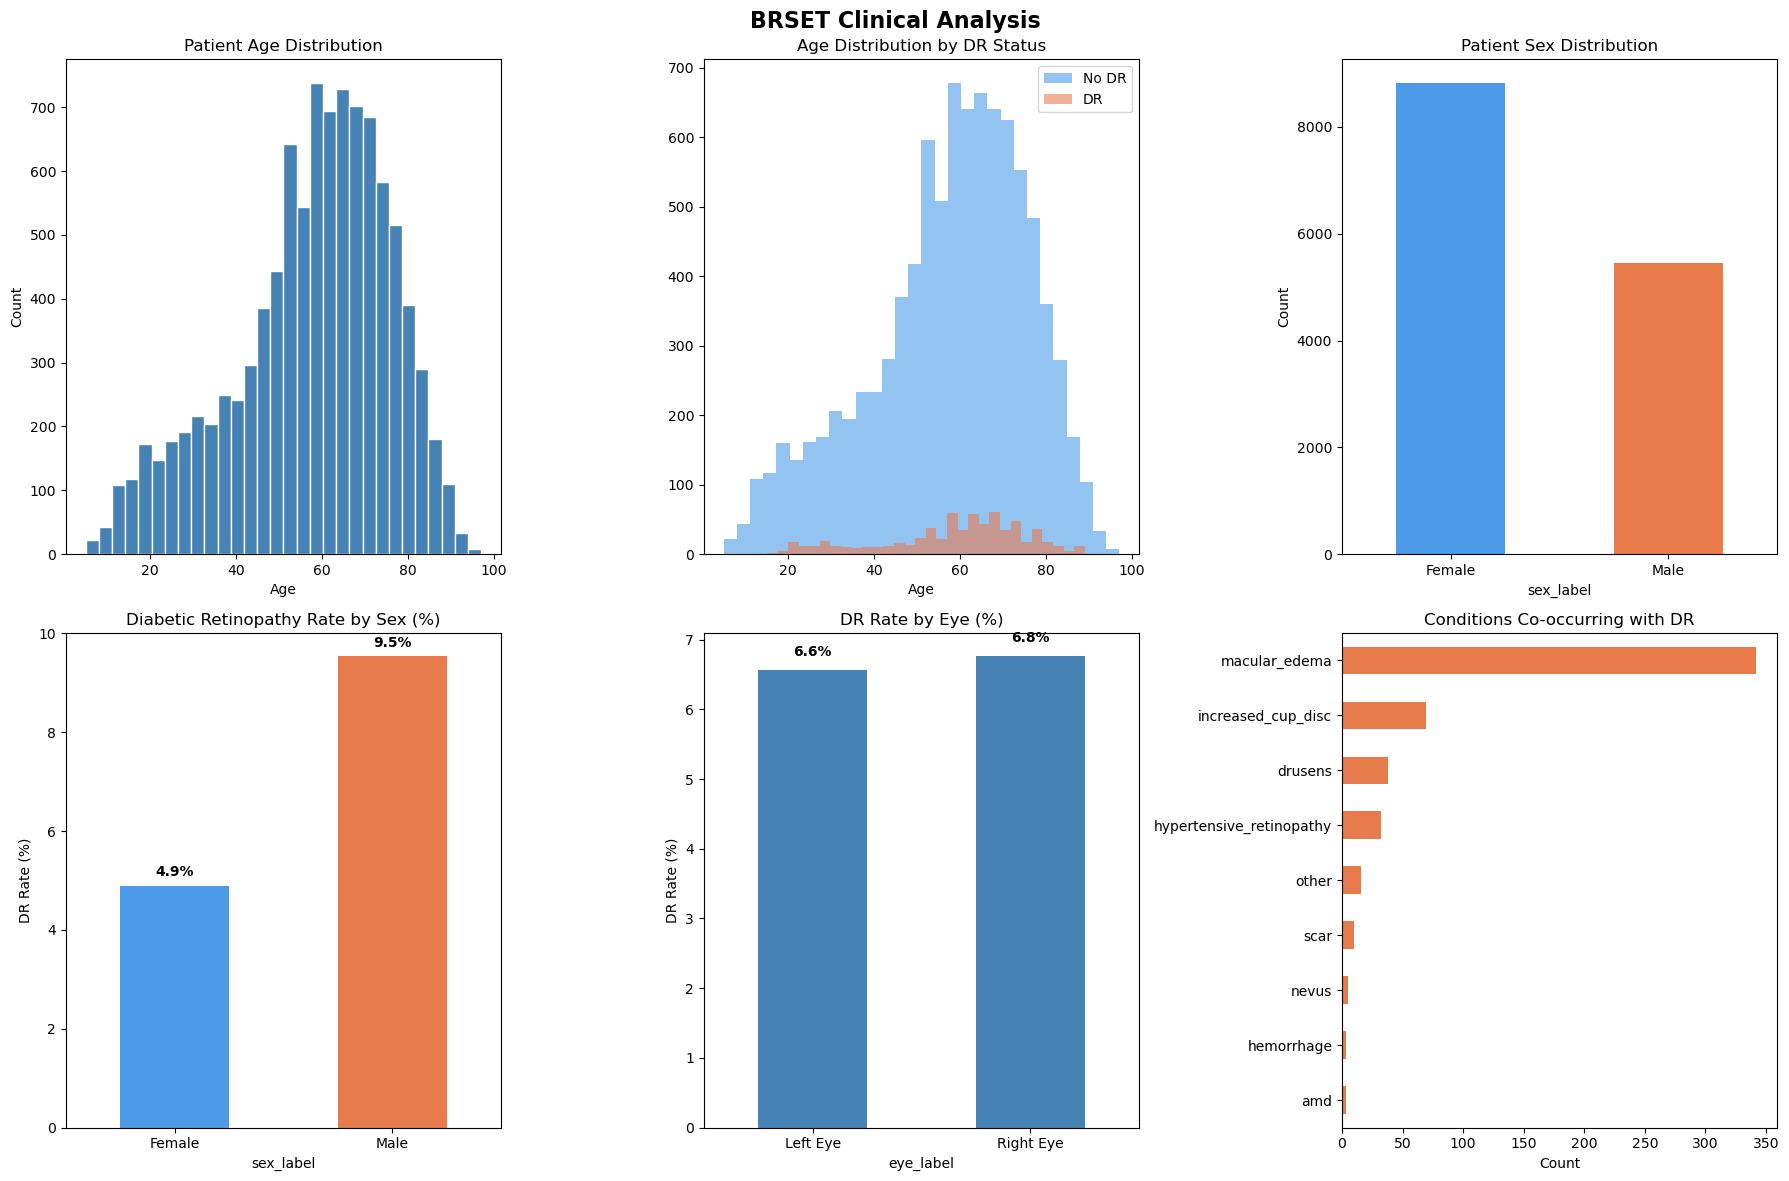

Clean dataset size: 14279


In [6]:
# Clinical analysis — age distribution and DR relationship
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('BRSET Clinical Analysis', fontsize=16, fontweight='bold')

# Filter to adequate quality images only
df_clean = df[df['quality'] == 'Adequate'].copy()
print(f"After quality filter: {len(df_clean)} images")

# Chart 1 — Age distribution
df_clean['patient_age'].dropna().plot(
    kind='hist', bins=30, ax=axes[0,0], color='steelblue', edgecolor='white'
)
axes[0,0].set_title('Patient Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Chart 2 — Age by DR status
dr_yes = df_clean[df_clean['diabetic_retinopathy']==1]['patient_age'].dropna()
dr_no = df_clean[df_clean['diabetic_retinopathy']==0]['patient_age'].dropna()
axes[0,1].hist(dr_no, bins=30, alpha=0.6, label='No DR', color='#4C9BE8')
axes[0,1].hist(dr_yes, bins=30, alpha=0.6, label='DR', color='#E87B4C')
axes[0,1].set_title('Age Distribution by DR Status')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Chart 3 — Sex distribution
sex_map = {1: 'Male', 2: 'Female'}
df_clean['sex_label'] = df_clean['patient_sex'].map(sex_map)
df_clean['sex_label'].value_counts().plot(
    kind='bar', ax=axes[0,2], color=['#4C9BE8','#E87B4C']
)
axes[0,2].set_title('Patient Sex Distribution')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=0)

# Chart 4 — DR rate by sex
dr_by_sex = df_clean.groupby('sex_label')['diabetic_retinopathy'].mean() * 100
dr_by_sex.plot(kind='bar', ax=axes[1,0], color=['#4C9BE8','#E87B4C'])
axes[1,0].set_title('Diabetic Retinopathy Rate by Sex (%)')
axes[1,0].set_ylabel('DR Rate (%)')
axes[1,0].tick_params(axis='x', rotation=0)
for i, v in enumerate(dr_by_sex.values):
    axes[1,0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 5 — DR by exam eye
eye_map = {1: 'Right Eye', 2: 'Left Eye'}
df_clean['eye_label'] = df_clean['exam_eye'].map(eye_map)
dr_by_eye = df_clean.groupby('eye_label')['diabetic_retinopathy'].mean() * 100
dr_by_eye.plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('DR Rate by Eye (%)')
axes[1,1].set_ylabel('DR Rate (%)')
axes[1,1].tick_params(axis='x', rotation=0)
for i, v in enumerate(dr_by_eye.values):
    axes[1,1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 6 — Co-occurring conditions with DR
dr_cases = df_clean[df_clean['diabetic_retinopathy']==1]
cooccur = dr_cases[disease_cols].drop(columns='diabetic_retinopathy').sum()
cooccur = cooccur[cooccur > 0].sort_values(ascending=True)
cooccur.plot(kind='barh', ax=axes[1,2], color='#E87B4C')
axes[1,2].set_title('Conditions Co-occurring with DR')
axes[1,2].set_xlabel('Count')

plt.tight_layout()
save_path = os.path.expanduser('~/brset_clinical_analysis.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Clean dataset size: {len(df_clean)}")

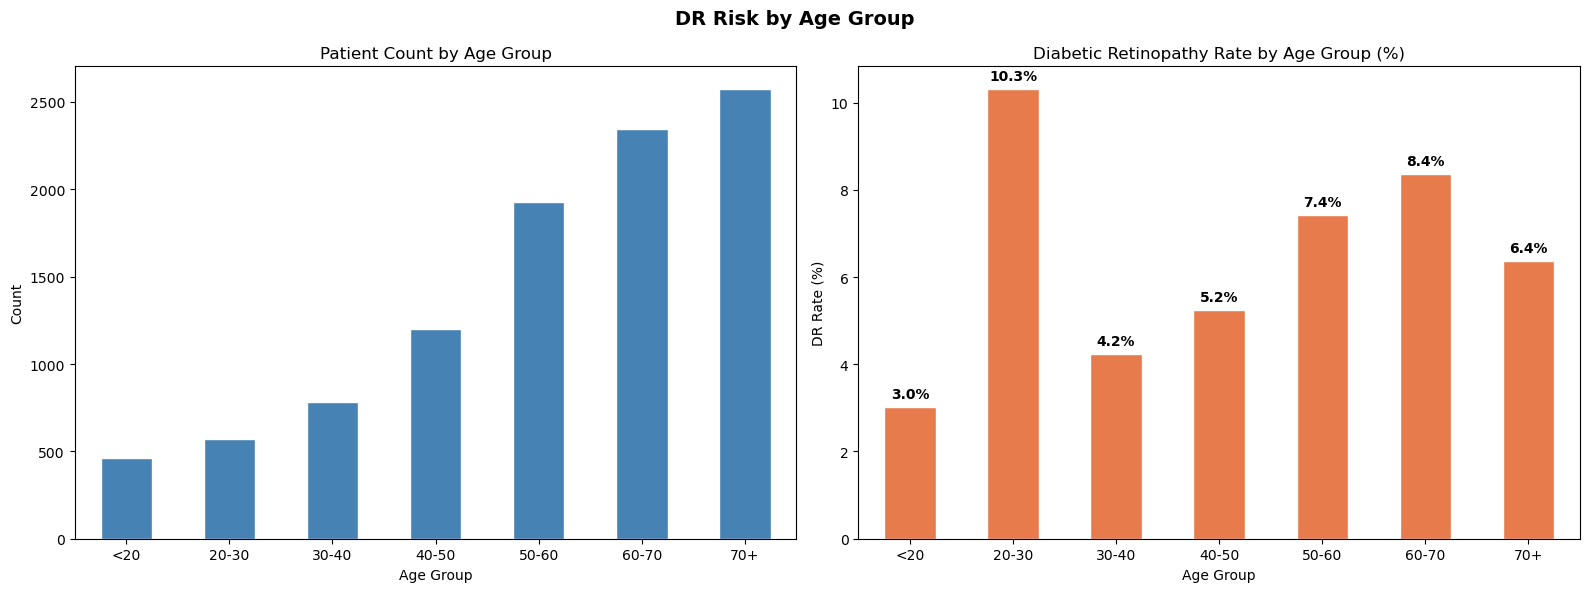


DR rate by age group:
age_group
<20       3.02
20-30    10.31
30-40     4.23
40-50     5.25
50-60     7.43
60-70     8.37
70+       6.37
Name: diabetic_retinopathy, dtype: float64


In [7]:
# Age group analysis
df_clean['age_group'] = pd.cut(df_clean['patient_age'], 
                                bins=[0, 20, 30, 40, 50, 60, 70, 100],
                                labels=['<20', '20-30', '30-40', '40-50', 
                                        '50-60', '60-70', '70+'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DR Risk by Age Group', fontsize=14, fontweight='bold')

# Chart 1 — Patient count by age group
df_clean['age_group'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Patient Count by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2 — DR rate by age group
dr_by_age = df_clean.groupby('age_group', observed=True)['diabetic_retinopathy'].mean() * 100
dr_by_age.plot(kind='bar', ax=axes[1], color='#E87B4C', edgecolor='white')
axes[1].set_title('Diabetic Retinopathy Rate by Age Group (%)')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('DR Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(dr_by_age.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
save_path = os.path.expanduser('~/brset_age_analysis.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("\nDR rate by age group:")
print(dr_by_age.round(2))

In [8]:
# Check comorbidity types in 20-30 age group
young = df_clean[df_clean['age_group'] == '20-30']
print("20-30 age group comorbidities:")
print(young['comorbidities'].value_counts().head(10))

print(f"\nTotal 20-30 patients: {len(young)}")
print(f"DR cases in 20-30: {young['diabetic_retinopathy'].sum()}")

# Compare with 50-60
middle = df_clean[df_clean['age_group'] == '50-60']
print("\n50-60 age group comorbidities:")
print(middle['comorbidities'].value_counts().head(10))

20-30 age group comorbidities:
comorbidities
0                         198
diabetes1                 151
diabetes1, SAH             25
rhinitis                    5
SAH                         5
hypothyroidism              4
hydroxichloroquine          2
epilepsy                    2
chronic kidney disease      2
lupus                       2
Name: count, dtype: int64

Total 20-30 patients: 572
DR cases in 20-30: 59

50-60 age group comorbidities:
comorbidities
0                            510
SAH                          297
diabetes                     196
diabetes, SAH                148
hypothyroidism                23
hypercholesterolemia          15
diabetes1                     10
SAH, hypothyroidism           10
dyslipidemia                   9
SAH, hypercholesterolemia      8
Name: count, dtype: int64


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Prepare features — only use columns with reasonable data
# Drop high-missing columns: diabetes_time_y, insuline
features = ['patient_age', 'patient_sex', 'exam_eye', 
            'optic_disc', 'vessels', 'macula',
            'focus', 'iluminaton', 'image_field', 'artifacts']

target = 'diabetic_retinopathy'

# Work with clean quality images only
df_model = df_clean[features + [target]].dropna()
print(f"Modeling dataset size: {len(df_model)}")
print(f"DR cases: {df_model[target].sum()}")
print(f"No DR cases: {(df_model[target]==0).sum()}")

X = df_model[features]
y = df_model[target]

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train)}")
print(f"Test set: {len(X_test)}")
print(f"\nDR rate in training: {y_train.mean()*100:.1f}%")
print(f"DR rate in test: {y_test.mean()*100:.1f}%")

Modeling dataset size: 9858
DR cases: 672
No DR cases: 9186

Training set: 7886
Test set: 1972

DR rate in training: 6.8%
DR rate in test: 6.8%


In [10]:
# Build Random Forest with class balancing
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles 93/7 imbalance
    random_state=42,
    n_jobs=-1  # uses all CPU cores
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Results
print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['No DR', 'Diabetic Retinopathy']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"True Negatives (correctly predicted No DR): {cm[0,0]}")
print(f"False Positives (incorrectly flagged as DR): {cm[0,1]}")
print(f"False Negatives (missed DR cases): {cm[1,0]}")
print(f"True Positives (correctly identified DR): {cm[1,1]}")

Classification Report:
                      precision    recall  f1-score   support

               No DR       0.96      0.85      0.90      1838
Diabetic Retinopathy       0.18      0.46      0.26       134

            accuracy                           0.82      1972
           macro avg       0.57      0.66      0.58      1972
        weighted avg       0.90      0.82      0.86      1972


ROC-AUC Score: 0.735

Confusion Matrix:
True Negatives (correctly predicted No DR): 1562
False Positives (incorrectly flagged as DR): 276
False Negatives (missed DR cases): 72
True Positives (correctly identified DR): 62


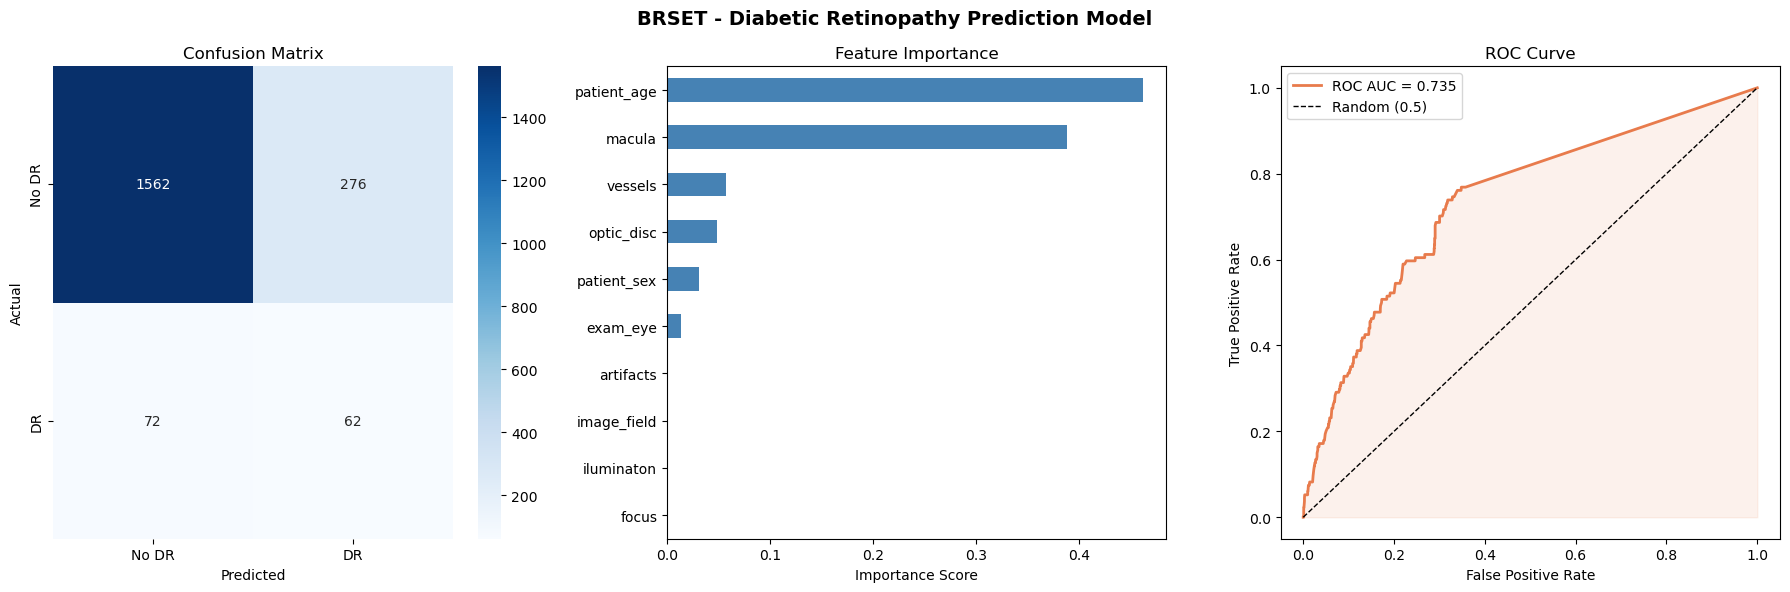

Saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('BRSET - Diabetic Retinopathy Prediction Model', 
             fontsize=14, fontweight='bold')

# Chart 1 — Confusion matrix heatmap
import seaborn as sns
cm_display = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_display, annot=True, fmt='d', ax=axes[0],
            cmap='Blues',
            xticklabels=['No DR', 'DR'],
            yticklabels=['No DR', 'DR'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Chart 2 — Feature importance
feat_imp = pd.Series(rf_model.feature_importances_, 
                     index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

# Chart 3 — ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr, tpr, color='#E87B4C', linewidth=2,
             label=f'ROC AUC = 0.735')
axes[2].plot([0,1], [0,1], 'k--', linewidth=1, label='Random (0.5)')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#E87B4C')

plt.tight_layout()
save_path = os.path.expanduser('~/brset_model_results.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, recall_score

# Compare multiple models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_m = model.predict(X_test)
    y_prob_m = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_test, y_prob_m), 3),
        'DR Recall': round(recall_score(y_test, y_pred_m), 3),
        'DR F1': round(f1_score(y_test, y_pred_m), 3),
        'Accuracy': round((y_pred_m == y_test).mean(), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  ROC-AUC  DR Recall  DR F1  Accuracy
      Random Forest    0.735      0.463  0.263     0.824
Logistic Regression    0.830      0.813  0.314     0.759
                KNN    0.691      0.097  0.157     0.929


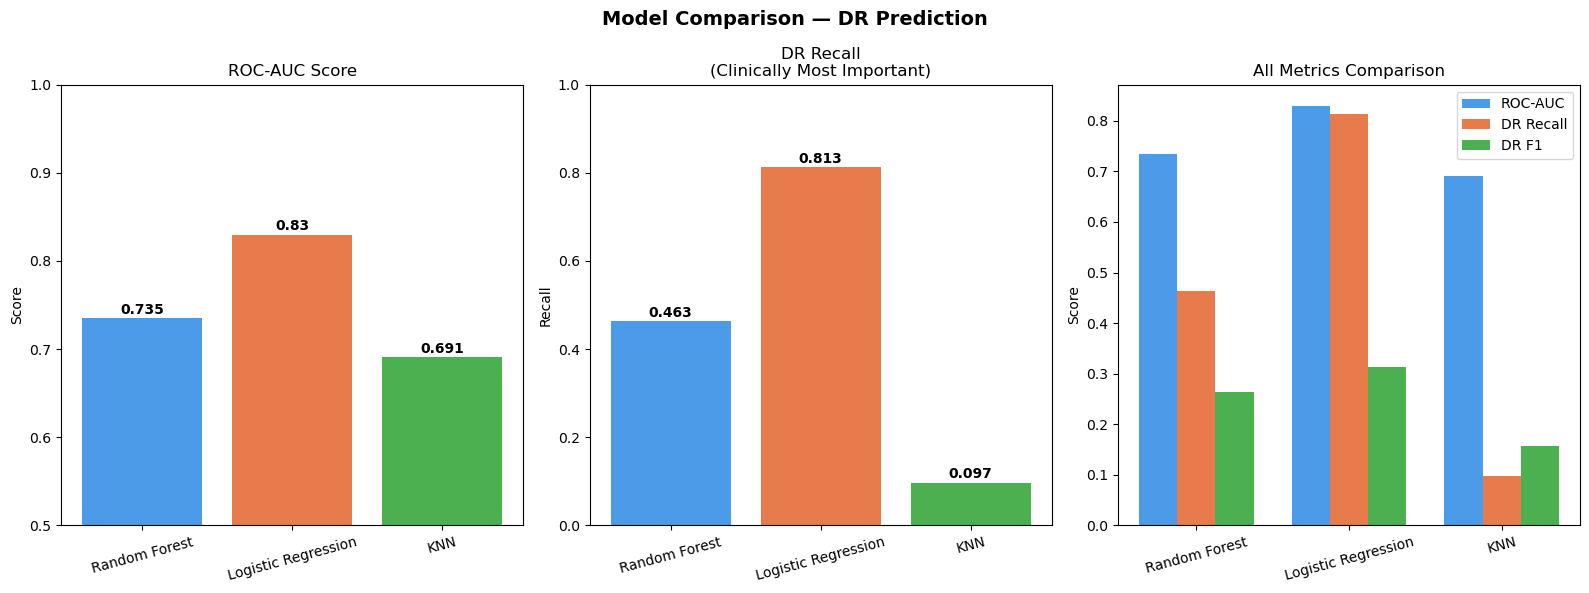

Saved!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Model Comparison — DR Prediction', fontsize=14, fontweight='bold')

colors = ['#4C9BE8', '#E87B4C', '#4CAF50']

# Chart 1 — ROC-AUC comparison
axes[0].bar(results_df['Model'], results_df['ROC-AUC'], color=colors)
axes[0].set_title('ROC-AUC Score')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['ROC-AUC']):
    axes[0].text(i, v + 0.005, str(v), ha='center', fontweight='bold')

# Chart 2 — DR Recall comparison
axes[1].bar(results_df['Model'], results_df['DR Recall'], color=colors)
axes[1].set_title('DR Recall\n(Clinically Most Important)')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['DR Recall']):
    axes[1].text(i, v + 0.01, str(v), ha='center', fontweight='bold')

# Chart 3 — All metrics side by side
x = np.arange(len(results_df['Model']))
width = 0.25
axes[2].bar(x - width, results_df['ROC-AUC'], width, label='ROC-AUC', color='#4C9BE8')
axes[2].bar(x, results_df['DR Recall'], width, label='DR Recall', color='#E87B4C')
axes[2].bar(x + width, results_df['DR F1'], width, label='DR F1', color='#4CAF50')
axes[2].set_title('All Metrics Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results_df['Model'], rotation=15)
axes[2].legend()
axes[2].set_ylabel('Score')

plt.tight_layout()
save_path = os.path.expanduser('~/brset_model_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")